# When the pros are all-in, should you sell? 📉
### The NAAIM manager-exposure index as a contrarian tell, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pros_smarter%3F: Not_supported](https://img.shields.io/badge/Pros_smarter%3F-Not_supported-8b949e?style=flat-square)

Every Wednesday, a group of professional money managers (NAAIM) reports how much of their clients' money is actually **in the stock market** right now -- from **0%** (everything in cash) to **200%** (leveraged double-long). The folklore: this is the *smart money*, so when they're **all-in** the easy gains are over (**sell**), and when they've **bailed to cash** the bottom is near (**buy**). Do the opposite of the pros and win.

It's a great story, and the **direction** is genuinely right -- weeks *after* the pros panic really do beat weeks *after* they pile in. But the effect is small, unreliable, and as a trading rule it **loses to just staying invested**. This notebook shows why.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the predictive regression and the cost-charged overlay? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** -- research and education. Every chart below is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from naaim_exposure import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.build_real_panel() if True else None   # always builds (weekly cache or real fallback)
print("real NAAIM weekly cache present:", HAVE_REAL, "| weeks in panel:", len(PANEL))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2006-07-05 -> 2026-06-10', 'weeks': 1040, 'fp': 'b887999dd648', 'naaim_lo': -3.6, 'naaim_hi': 120.6, 'naaim_mean': 67.3, 'uncond_yr': 12.0, 'uncond_t': 3.42, 'low_yr': 16.2, 'low_t': 1.92, 'low_n': 347, 'mid_yr': 11.3, 'mid_t': 2.15, 'mid_n': 346, 'high_yr': 8.6, 'high_t': 2.49, 'high_n': 347, 'gap_yr': 7.6, 'ls_yr': 2.52, 'ls_t': 0.81, 'beta_sd': -0.04, 'beta_t': -0.4, 'r2': 0.0003, 'ov_yr': 8.68, 'ov_sr': 0.57, 'ov_t': 2.72, 'ov_inmkt': 67, 'bh_yr': 12.04, 'bh_sr': 0.73, 'sub': [('2006-2012', 6.3, 0.34, 1.2, 0.17, 339), ('2013-2019', 22.5, 2.28, 12.2, 2.57, 364), ('2020-2026', 22.0, 1.37, 12.0, 1.54, 337)], 'syn_null_t': -0.37, 'syn_edge': 0.004, 'syn_edge_t': -6.12}


real NAAIM weekly cache present: True | weeks in panel: 1040


## The answer first

| Question | Answer |
|---|---|
| Do weeks after the pros bail to cash beat weeks after they go all-in? | **Yes -- in direction.** Cash-regime weeks earn **+16%/yr** next week vs **+9%/yr** for all-in weeks -- a **8 pp/yr** gap, the contrarian way. |
| So fade the pros for profit? | **No.** The gap isn't statistically reliable (it fails the significance bar), and *every* regime -- even all-in -- still earns a solid **positive** return. "All-in" is a smaller buy, not a sell. |
| Does a contrarian timing rule beat buy-and-hold? | **No -- it loses.** Sitting out the all-in weeks nets **+8.7%/yr** vs **+12.0%/yr** for just staying invested. The pros go all-in *during* the best part of bull markets. |
| Are the pros smarter than retail here? | **No.** This professional gauge gives the **same** weak, untradeable tilt as the individual-investor survey ([Study 257](../../257-aaii-sentiment/)). |

> The direction is real. The edge is too small to bank, and fading the pros means skipping the rallies they were right to ride.

## 1 · The claim

> *"The NAAIM Exposure Index tells you what professional active managers are actually doing with their money -- not what they say, what they **do**. When they're maxed out (near 100-200%), the market is over-loved and due to fall: sell. When they've fled to cash (near 0), everyone who was going to sell already has: buy. It's the smart money, so fading its extremes beats fading a retail poll."*

The index has been published **free, weekly, since July 2006**. It's the mean equity exposure across NAAIM member firms on a **0-200%** scale. We take it at its strongest: real positioning by people who trade for a living.

## 2 · So what?

If true, this would be a free, public, weekly market-timing signal -- and it would say something deep: that the people *closest* to the market are systematically wrong at the extremes, and that you can profit just by doing the opposite. That's a strong claim about how markets work. Two things have to hold for it to pay: (1) the exposure reading this week has to actually *predict* next week's return, and (2) trading on it has to beat the dead-simple alternative of buying and holding. We can measure both directly.

## 3 · How would we even know?

We line up **1,040 weeks** of the real NAAIM number (2006-07-05 -> 2026-06-10) against the **total return** of SPY (the S&P 500 ETF, dividends reinvested). For each week we know the managers' exposure *now* and the market's return over the *following* week -- everything the rule sees, plus the answer.

1. **Sort by the pros' positioning.** Split weeks into low / middle / high exposure and compare next week's return. Contrarian = low beats high.
2. **Trade it honestly.** Build a rule that sits out the all-in weeks and stays long otherwise, charge it realistic costs, and race it against buy-and-hold.
3. **What would make us say "mirage"?** If the gap isn't statistically reliable, or the rule loses to buy-and-hold once it pays for the upside it skips.

## 4 · The teardown -- let's actually look

**First: which way does it lean?** Next-week SPY return, split by how exposed the pros were the week before.

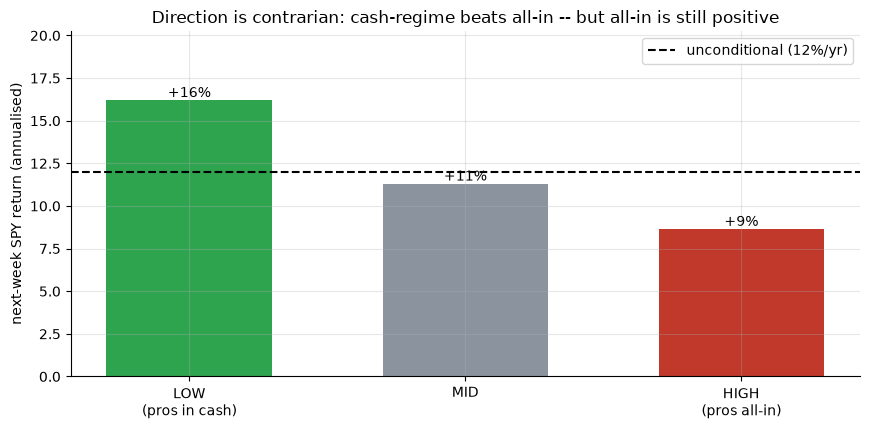

low / mid / high  %/yr: ['+16.2', '+11.3', '+8.6']


In [2]:
if HAVE_REAL:
    rs = st.regime_summary(PANEL)
    yrs = [rs.loc[k,'mean_ann']*100 for k in ('low','mid','high')]
else:
    yrs = [R['low_yr'], R['mid_yr'], R['high_yr']]
labels = ['LOW\n(pros in cash)', 'MID', 'HIGH\n(pros all-in)']
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(labels, yrs, color=[GREEN, GREY, RED], width=.6)
ax.axhline(R['uncond_yr'], ls='--', c='k', label=f"unconditional ({R['uncond_yr']:.0f}%/yr)")
for i,v in enumerate(yrs): ax.annotate(f'{v:+.0f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('next-week SPY return (annualised)'); ax.set_ylim(0, max(yrs)*1.25)
ax.set_title('Direction is contrarian: cash-regime beats all-in -- but all-in is still positive')
ax.legend(); plt.tight_layout(); plt.show()
print('low / mid / high  %/yr:', [f'{v:+.1f}' for v in yrs])

The lean is the contrarian one: after the pros bail to cash, the next week runs **+16%/yr**; after they're all-in, **+9%/yr** -- a **8 pp/yr** gap. **But look at the all-in bar: it's still firmly positive.** "The pros are maxed out" has never meant "the market falls" -- it's meant "the market rises a bit less." That's already fatal to a *sell* signal.

**Now the catch: can you trade it?** Build the contrarian rule -- stay long, but step aside whenever the pros are all-in -- charge it costs, and race it against simply buying and holding SPY.

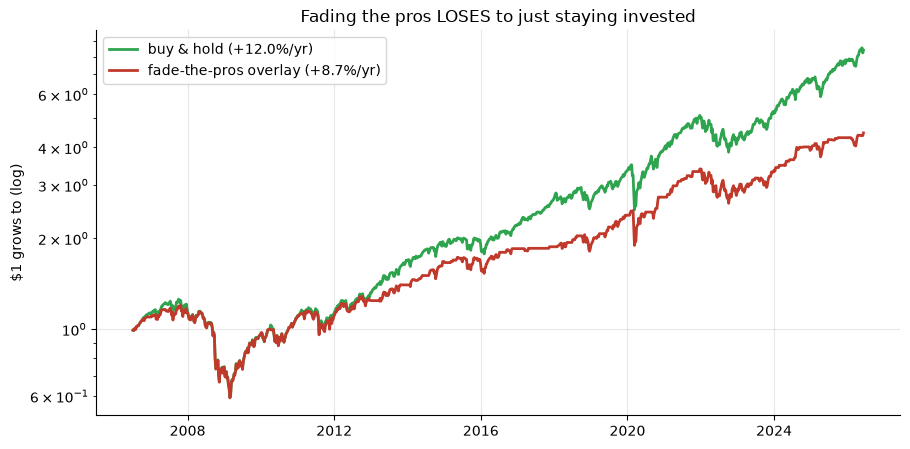

overlay +8.7%/yr  vs  buy-and-hold +12.0%/yr


In [3]:
if HAVE_REAL:
    ov = st.timing_overlay(PANEL, one_way_bps=5.0)
    eq_ov = (1+ov['net']).cumprod(); eq_bh = (1+ov['bh']).cumprod()
    ov_yr = st.summarize(ov['net'])['mean']*5200; bh_yr = st.summarize(ov['bh'])['mean']*5200
    fig, ax = plt.subplots(figsize=(9.2, 4.6))
    ax.plot(eq_bh.index, eq_bh.values, c=GREEN, lw=2, label=f'buy & hold ({bh_yr:+.1f}%/yr)')
    ax.plot(eq_ov.index, eq_ov.values, c=RED, lw=2, label=f'fade-the-pros overlay ({ov_yr:+.1f}%/yr)')
    ax.set_yscale('log'); ax.set_ylabel('$1 grows to (log)')
else:
    fig, ax = plt.subplots(figsize=(9.2, 4.6)); ov_yr, bh_yr = R['ov_yr'], R['bh_yr']
    ax.bar(['fade-the-pros\noverlay','buy & hold'],[ov_yr,bh_yr],color=[RED,GREEN],width=.5)
    for i,v in enumerate([ov_yr,bh_yr]): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',va='bottom')
    ax.set_ylabel('annualised return')
ax.set_title('Fading the pros LOSES to just staying invested'); ax.legend()
plt.tight_layout(); plt.show()
print(f'overlay {ov_yr:+.1f}%/yr  vs  buy-and-hold {bh_yr:+.1f}%/yr')

There it is. The contrarian overlay nets **+8.7%/yr**; buy-and-hold makes **+12.0%/yr**. Stepping aside when the pros are all-in means stepping aside during the strongest stretches of bull markets -- exactly the weeks the pros were right to ride. **The direction was real; the trade still loses.**

## 5 · The verdict

- **Signal -- Weak.** The contrarian direction is real (cash +16%/yr vs all-in +9%/yr) and shows up in every era, but it's not statistically reliable and explains almost none of next-week's moves.
- **Tradability -- Mirage.** The overlay nets **+8.7%/yr** vs **+12.0%/yr** for buy-and-hold. Fading the pros skips the rallies.
- **Pros smarter than retail? -- Not supported.** Same weak, untradeable tilt as the individual-investor survey. Knowing what the pros *do* is no more bankable than knowing what retail *thinks*.

## 6 · Could you actually trade it? -- why the pros go all-in

Here's the trap, in one picture. Plot the managers' exposure on top of the market. Notice **when** they're all-in: not at random tops, but right in the middle of the uptrends -- because they're (sensibly) trend-following. Fade that, and you're shorting the trend.

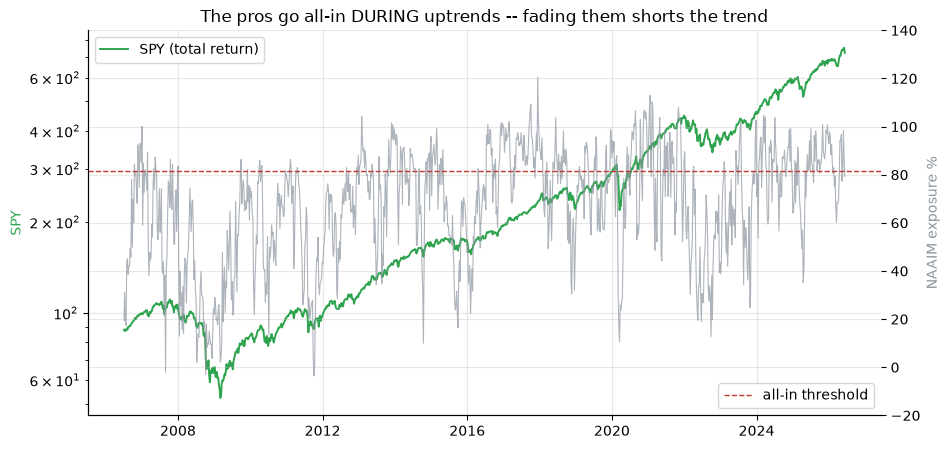

NAAIM range on the tape: -4..121 (mean 67)


In [4]:
if HAVE_REAL:
    p = PANEL
    spy = data.fetch_spy()
    lvl = spy.reindex(p.index, method='ffill')
    fig, ax1 = plt.subplots(figsize=(9.6, 4.6))
    ax1.plot(lvl.index, lvl.values, c=GREEN, lw=1.4, label='SPY (total return)')
    ax1.set_ylabel('SPY', color=GREEN); ax1.set_yscale('log')
    ax2 = ax1.twinx()
    ax2.plot(p.index, p['naaim'].values, c=GREY, lw=.8, alpha=.7)
    ax2.axhline(p['naaim'].quantile(2/3), ls='--', c=RED, lw=1, label='all-in threshold')
    ax2.set_ylabel('NAAIM exposure %', color=GREY); ax2.set_ylim(-20, 140)
    ax1.set_title('The pros go all-in DURING uptrends -- fading them shorts the trend')
    ax1.legend(loc='upper left'); ax2.legend(loc='lower right')
else:
    fig, ax = plt.subplots(figsize=(9.6,4.6))
    ax.text(.5,.5,'(real tape cache absent -- see docs/results.md)',ha='center')
plt.tight_layout(); plt.show()
print('NAAIM range on the tape:', f"{R['naaim_lo']:.0f}..{R['naaim_hi']:.0f}", '(mean', f"{R['naaim_mean']:.0f})")

> The pros' exposure rises *with* the market and falls *with* it. "Be greedy when the pros are fearful" sounds bold, but mechanically it's "buy after a crash, sell after a rally" -- a weak, pro-cyclical bet that occasionally nails a bottom (2009, 2020) and otherwise just costs you the upside.

## 7 · Going further 🚪

- **The retail twin.** [Study 257 -- AAII](../../257-aaii-sentiment/): the same contrarian template on the *individual-investor* survey -- same WEAK / MIRAGE verdict. The crowd-vs-pros head-to-head is the punchline: neither is bankable.
- **The options crowd & leverage.** [Study 261 -- put/call](../../261-put-call-ratio/) and [Study 260 -- margin-debt](../../260-margin-debt/) -- two more sentiment gauges, same fate.
- **Try harder yourself.** Z-score the exposure, demand a multi-week extreme, or only fade *both* an all-in print *and* an overbought tape. The package is offline and deterministic -- fork [`naaim_exposure/`](../naaim_exposure/) and see if any variant clears the bar (we couldn't).

*Think a cleaner NAAIM rule beats buy-and-hold after costs? Build it on this exact tape and show the *t*-stat -- then check it isn't just riding a couple of ex-post-obvious rebounds.*